# Exploratory Data Analysis (EDA) on Open-Meteo Dataset

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from src.enums import measurements, aq_keys
from pandas.api.types import is_numeric_dtype

aq = pd.read_csv('02-28-open-meteo-2023-2026.csv')

## A1. Understand air quality features
Identify what kind of information is in each column, such as measurement and description.

In [36]:
aq_measurements = {
    aq_keys['time']: measurements['interval'],
    aq_keys['us_aqi (USAQI)']: measurements['ordinal'],
    aq_keys['us_aqi_pm2_5 (USAQI)']: measurements['ordinal'],
    aq_keys['us_aqi_pm10 (USAQI)']: measurements['ordinal'],
    aq_keys['us_aqi_nitrogen_dioxide (USAQI)']: measurements['ordinal'],
    aq_keys['us_aqi_carbon_monoxide (USAQI)']: measurements['ordinal'],
    aq_keys['us_aqi_ozone (USAQI)']: measurements['ordinal'],
    aq_keys['us_aqi_sulphur_dioxide (USAQI)']: measurements['ordinal'],
    aq_keys['methane (μg/m³)']: measurements['ratio'],
    aq_keys['uv_index_clear_sky ()']: measurements['ratio'],
    aq_keys['uv_index ()']: measurements['ratio'],
    aq_keys['dust (μg/m³)']: measurements['ratio'],
    aq_keys['aerosol_optical_depth ()']: measurements['ratio'],
    aq_keys['ozone (μg/m³)']: measurements['ratio'],
    aq_keys['sulphur_dioxide (μg/m³)']: measurements['ratio'],
    aq_keys['nitrogen_dioxide (μg/m³)']: measurements['ratio'],
    aq_keys['carbon_dioxide (ppm)']: measurements['ratio'],
    aq_keys['pm2_5 (μg/m³)']: measurements['ratio'],
    aq_keys['carbon_monoxide (μg/m³)']: measurements['ratio'],
    aq_keys['pm10 (μg/m³)']: measurements['ratio']
}
aq_descriptions = {
    aq_keys['time']: "Time of the measurement.",
    aq_keys['us_aqi (USAQI)']: "Air Quality Index is the overall standardized levels of health risk or air pollution.",
    aq_keys['us_aqi_pm2_5 (USAQI)']: "AQI for PM2.5 particles.",
    aq_keys['us_aqi_pm10 (USAQI)']: "AQI for PM10 particles.",
    aq_keys['us_aqi_nitrogen_dioxide (USAQI)']: "AQI for Nitrogen Dioxide.",
    aq_keys['us_aqi_carbon_monoxide (USAQI)']: "AQI for Carbon Monoxide.",
    aq_keys['us_aqi_ozone (USAQI)']: "AQI for Ozone.",
    aq_keys['us_aqi_sulphur_dioxide (USAQI)']: "AQI for Sulphur Dioxide.",
    aq_keys['methane (μg/m³)']: "A potent greenhouse gas that increases ozone levels.",
    aq_keys['uv_index_clear_sky ()']: "Measurement of the intensity of ultraviolet radiation from the sun under clear sky conditions, high levels can cause sunburn and skin cancer.",
    aq_keys['uv_index ()']: "Measurement of the intensity of ultraviolet radiation from the sun, high levels can cause sunburn and skin cancer.",
    aq_keys['dust (μg/m³)']: "Dust particles in the air that can cause coughing, wheezing, and asthma attacks.",
    aq_keys['aerosol_optical_depth ()']: "Measure of how much sunlight is blocked by airborne particles. High AOD indicates high concentration of particulate matters (PM2.5 and PM10).",
    aq_keys['ozone (μg/m³)']: "Created by chemical reactions between oxides of nitrogen and sunlight, it is a powerful lung irritant that can trigger asthma.",
    aq_keys['sulphur_dioxide (μg/m³)']: "Produced by burning fossil fuels, it constricts airways and is particularly dangerous for people with asthma.",
    aq_keys['nitrogen_dioxide (μg/m³)']: "Vehicle emissions can cause airway inflammation.",
    aq_keys['carbon_dioxide (ppm)']: "Colorless gas produced by burning fossil fuels. Not harmful outdoors.",
    aq_keys['pm2_5 (μg/m³)']: "Tiny particles that can lodge deep in the lungs and enter the bloodstream.",
    aq_keys['carbon_monoxide (μg/m³)']: "Odorless gas from combustion, reduces oxygen delivery to organs.",
    aq_keys['pm10 (μg/m³)']: "Includes dust, pollen, mold and affects the upper respiratory tract."
}

aq.info()
pd.DataFrame({
    "Measurement Type": aq_measurements,
    "Description": aq_descriptions,
})

<class 'pandas.DataFrame'>
RangeIndex: 23208 entries, 0 to 23207
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   time                             23208 non-null  str    
 1   us_aqi (USAQI)                   23208 non-null  int64  
 2   us_aqi_pm2_5 (USAQI)             23208 non-null  int64  
 3   us_aqi_pm10 (USAQI)              23208 non-null  int64  
 4   us_aqi_nitrogen_dioxide (USAQI)  23208 non-null  int64  
 5   us_aqi_carbon_monoxide (USAQI)   23208 non-null  int64  
 6   us_aqi_ozone (USAQI)             23208 non-null  int64  
 7   us_aqi_sulphur_dioxide (USAQI)   23208 non-null  int64  
 8   methane (μg/m³)                  11624 non-null  float64
 9   uv_index_clear_sky ()            23208 non-null  float64
 10  uv_index ()                      23208 non-null  float64
 11  dust (μg/m³)                     23208 non-null  int64  
 12  aerosol_optical_depth ()     

,Measurement Type,Description
time,interval,Time of the measurement.
us_aqi (USAQI),ordinal,Air Quality Index is the overall standardized ...
us_aqi_pm2_5 (USAQI),ordinal,AQI for PM2.5 particles.
us_aqi_pm10 (USAQI),ordinal,AQI for PM10 particles.
us_aqi_nitrogen_dioxide (USAQI),ordinal,AQI for Nitrogen Dioxide.
us_aqi_carbon_monoxide (USAQI),ordinal,AQI for Carbon Monoxide.
us_aqi_ozone (USAQI),ordinal,AQI for Ozone.
us_aqi_sulphur_dioxide (USAQI),ordinal,AQI for Sulphur Dioxide.
methane (μg/m³),ratio,A potent greenhouse gas that increases ozone l...
uv_index_clear_sky (),ratio,Measurement of the intensity of ultraviolet ra...


## A2. Pre-narrow air quality data features
Based on feature descriptions, identify which features are unnecessary, and remove them to focus on relevant features and avoid wasting time.

In [37]:
# No column will be dropped.
aq_preview = aq.copy()
aq_preview['null_count'] = aq_preview.isnull().sum(axis=1)
aq_preview.sort_values('null_count', ascending=True).head(3).drop('null_count', axis=1)

,time,us_aqi (USAQI),us_aqi_pm2_5 (USAQI),us_aqi_pm10 (USAQI),us_aqi_nitrogen_dioxide (USAQI),us_aqi_carbon_monoxide (USAQI),us_aqi_ozone (USAQI),us_aqi_sulphur_dioxide (USAQI),methane (μg/m³),uv_index_clear_sky (),uv_index (),dust (μg/m³),aerosol_optical_depth (),ozone (μg/m³),sulphur_dioxide (μg/m³),nitrogen_dioxide (μg/m³),carbon_dioxide (ppm),pm2_5 (μg/m³),carbon_monoxide (μg/m³),pm10 (μg/m³)
23197,2026-02-21 13:00,32,32,8,1,2,31,1,1397.0,3.90,3.40,1,0.08,99,2.6,1.4,446.0,3.6,157,5.5
23196,2026-02-21 12:00,32,32,8,1,2,29,2,1404.0,4.10,3.65,1,0.07,93,3.0,2.1,446.0,3.8,170,5.6
23195,2026-02-21 11:00,32,32,8,2,2,26,2,1415.0,3.55,3.50,1,0.07,84,3.4,3.3,447.0,3.9,189,5.8


## A3. Assess air quality features

Document anomalies such as missing and NaN values. This will be referenced when fixing the data.

In [38]:
aq_assessment = aq.copy()
aq_assessment = aq_assessment.map(lambda row: row.strip().lower() if isinstance(row, str) else row)

aq_null_counts = {}
aq_null_percentages = {}
aq_duplicates = {}
aq_duplicate_percentages = {}

for key in aq_assessment.columns.tolist():
    null_count = aq_assessment[key].isna().sum()
    aq_null_counts[key] = null_count

    null_percentage = round((null_count / len(aq_assessment)) * 100, 2)
    aq_null_percentages[key] = null_percentage

    duplicates = aq_assessment[key].duplicated()
    duplicate_count = duplicates.sum()
    aq_duplicates[key] = duplicate_count

    duplicate_percentage = round((duplicate_count / len(aq_assessment)) * 100, 2)
    aq_duplicate_percentages[key] = duplicate_percentage

pd.DataFrame({
    'Null Count': aq_null_counts,
    'Null Percentage': aq_null_percentages,
    'Measurement Type': aq_measurements,
    'Duplicate Count': aq_duplicates,
    'Duplicate Percentage': aq_duplicate_percentages
})

,Null Count,Null Percentage,Measurement Type,Duplicate Count,Duplicate Percentage
time,0,0.00,interval,0,0.00
us_aqi (USAQI),0,0.00,ordinal,23111,99.58
us_aqi_pm2_5 (USAQI),0,0.00,ordinal,23119,99.62
us_aqi_pm10 (USAQI),0,0.00,ordinal,23178,99.87
us_aqi_nitrogen_dioxide (USAQI),0,0.00,ordinal,23170,99.84
us_aqi_carbon_monoxide (USAQI),0,0.00,ordinal,23197,99.95
us_aqi_ozone (USAQI),0,0.00,ordinal,23101,99.54
us_aqi_sulphur_dioxide (USAQI),0,0.00,ordinal,23196,99.95
methane (μg/m³),11584,49.91,ratio,22684,97.74
uv_index_clear_sky (),0,0.00,ratio,22986,99.04


## R4. Find central tendency of air quality features
Determine if the data is symmetrical. If the data is skewed, a more robust scaling method should be used, like log scaling.

In [ ]:
aq_assessment = aq.copy()

aq_mean = {}
aq_median = {}
aq_skew ={}
aq_skew_direction = {}

for key in aq_assessment.columns:
    if not is_numeric_dtype(aq_assessment[key]):
        aq_median[key] = 'N/A'
        aq_mean[key] = 'N/A'
        aq_skew[key] = 'N/A'
        aq_skew_direction[key] = 'N/A'
        continue

    mean = round(aq_assessment[key].mean(), 2)
    aq_mean[key] = mean

    median = round(aq_assessment[key].median(), 2)
    aq_median[key] = median

    skew = round(aq_assessment[key].skew(), 2)
    aq_skew[key] = skew

    if -0.5 <= skew <= 0.5:
        aq_skew_direction[key] = 'Symmetrical' # Mean = Median
    elif -1 <= skew < -0.5:
        aq_skew_direction[key] = 'Moderately Left Skewed' # Mean < Median
    elif skew < -1:
        aq_skew_direction[key] = 'Highly Left Skewed' # Mean < Median
    elif 0.5 < skew <= 1:
        aq_skew_direction[key] = 'Moderately Right Skewed' # Mean > Median
    elif skew > 1:
        aq_skew_direction[key] = 'Highly Right Skewed' # Mean > Median

pd.DataFrame({
    'Measurement Type': aq_measurements,
    'Mean': aq_mean,
    'Median': aq_median,
    'Skewness': aq_skew,
    'Skew Direction': aq_skew_direction
})

,Measurement Type,Mean,Median,Skewness,Skew Direction
time,interval,N/A,N/A,N/A,N/A
us_aqi (USAQI),ordinal,40.32,38.0,0.81,Moderately Right Skewed
us_aqi_pm2_5 (USAQI),ordinal,37.09,36.0,0.39,Symmetrical
us_aqi_pm10 (USAQI),ordinal,11.36,11.0,0.67,Moderately Right Skewed
us_aqi_nitrogen_dioxide (USAQI),ordinal,8.2,5.0,1.27,Highly Right Skewed
us_aqi_carbon_monoxide (USAQI),ordinal,2.36,2.0,1.75,Highly Right Skewed
us_aqi_ozone (USAQI),ordinal,25.05,25.0,0.58,Moderately Right Skewed
us_aqi_sulphur_dioxide (USAQI),ordinal,1.52,1.0,1.5,Highly Right Skewed
methane (μg/m³),ratio,1469.48,1445.0,1.52,Highly Right Skewed
uv_index_clear_sky (),ratio,1.43,0.0,1.88,Highly Right Skewed


## A5 - Measure variability of air quality features

In [ ]:
aq_assessment = aq.copy()

table_columns = ['Feature', 'q1', 'q3', 'iqr', 'std_dev', 'cv', 'lower_limit', 'upper_limit']
table_rows = []
for key in aq_assessment.columns:
    if not is_numeric_dtype(aq_assessment[key]):
        continue
    v = aq_assessment[key].dropna()
    q1 = np.percentile(v,25)
    q3 = np.percentile(v, 75)
    iqr = stats.iqr(v)
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    std_dev = np.std(v)
    cv = stats.variation(v)
    table_rows.append([
        key,
        q1,
        q3,
        iqr,
        std_dev,
        cv,
        lower_limit,
        upper_limit
    ])
aq_table = pd.DataFrame(data = table_rows, columns=table_columns)
aq_table

,Feature,q1,q3,iqr,std_dev,cv,lower_limit,upper_limit
0,us_aqi (USAQI),31.00,49.00,18.00,12.609684,0.312753,4.000,76.000
1,us_aqi_pm2_5 (USAQI),26.00,48.00,22.00,14.678415,0.395741,-7.000,81.000
2,us_aqi_pm10 (USAQI),8.00,14.00,6.00,4.497116,0.395870,-1.000,23.000
3,us_aqi_nitrogen_dioxide (USAQI),2.00,12.00,10.00,7.549652,0.921147,-13.000,27.000
4,us_aqi_carbon_monoxide (USAQI),2.00,3.00,1.00,1.139675,0.482058,0.500,4.500
5,us_aqi_ozone (USAQI),16.00,33.00,17.00,12.248944,0.488939,-9.500,58.500
6,us_aqi_sulphur_dioxide (USAQI),1.00,2.00,1.00,1.041692,0.683080,-0.500,3.500
7,methane (μg/m³),1403.00,1510.00,107.00,91.098563,0.061994,1242.500,1670.500
8,uv_index_clear_sky (),0.00,1.95,1.95,2.422870,1.696295,-2.925,4.875
9,uv_index (),0.00,1.55,1.55,2.299341,1.782996,-2.325,3.875


## A6 - Visualize distribution of air quality features

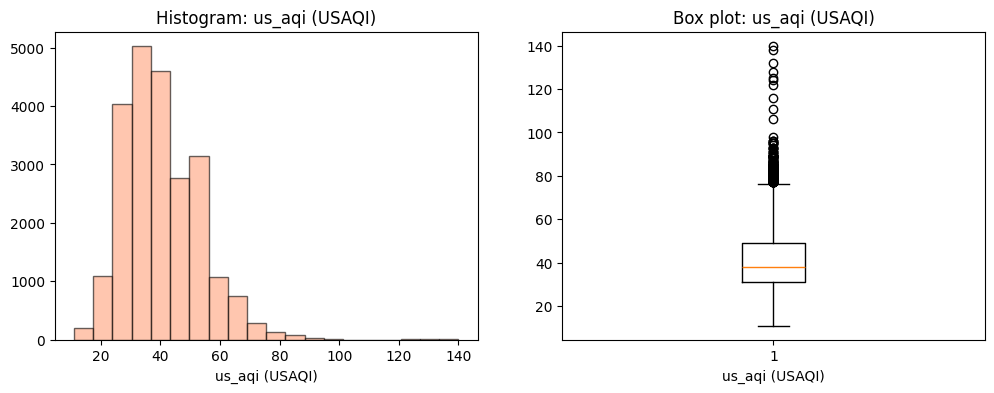

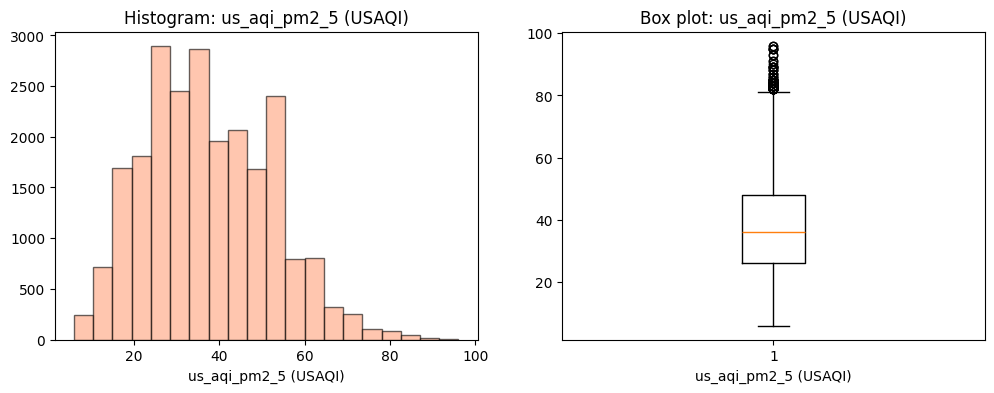

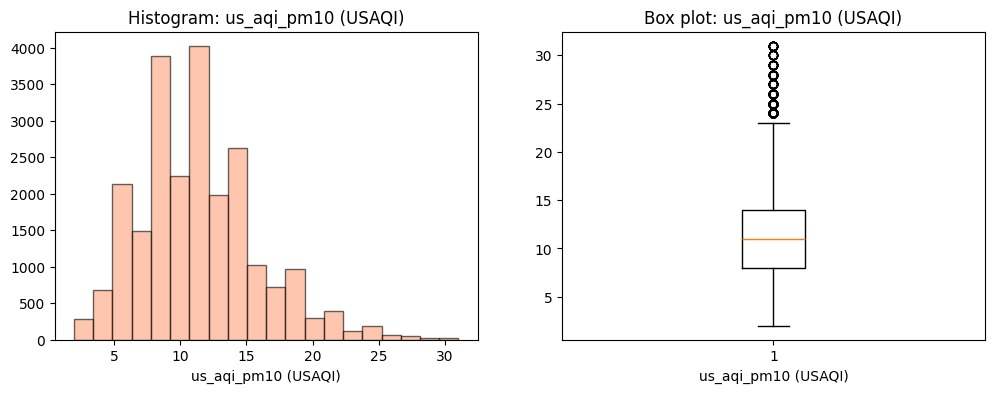

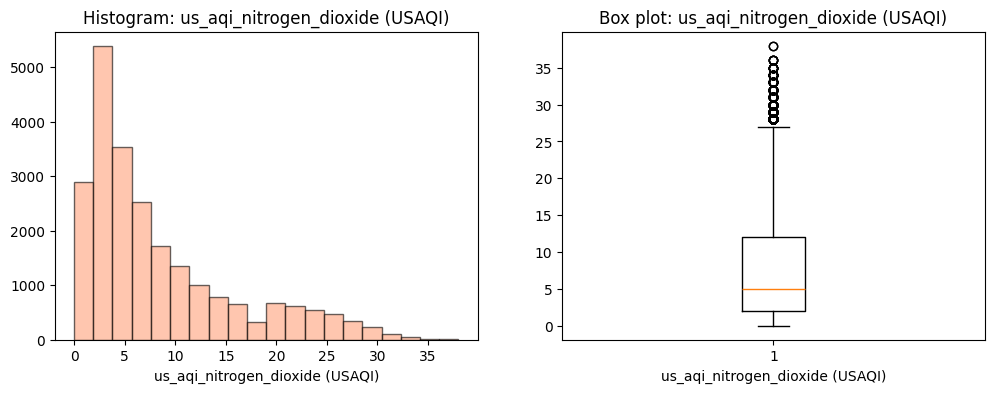

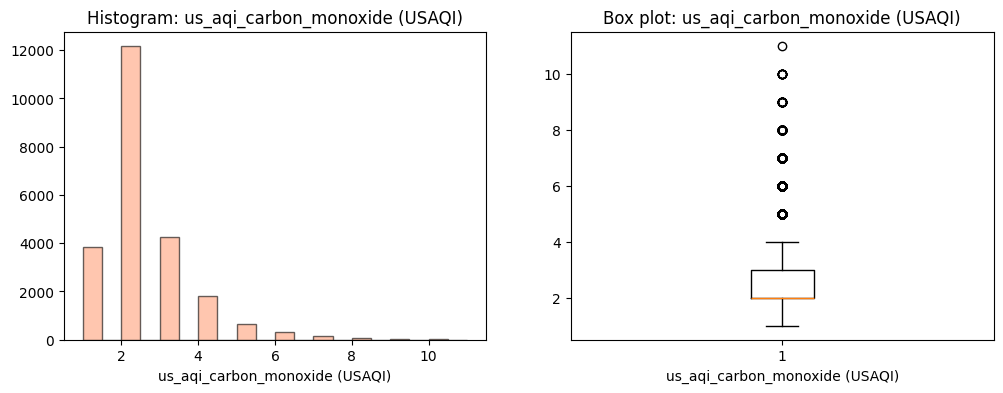

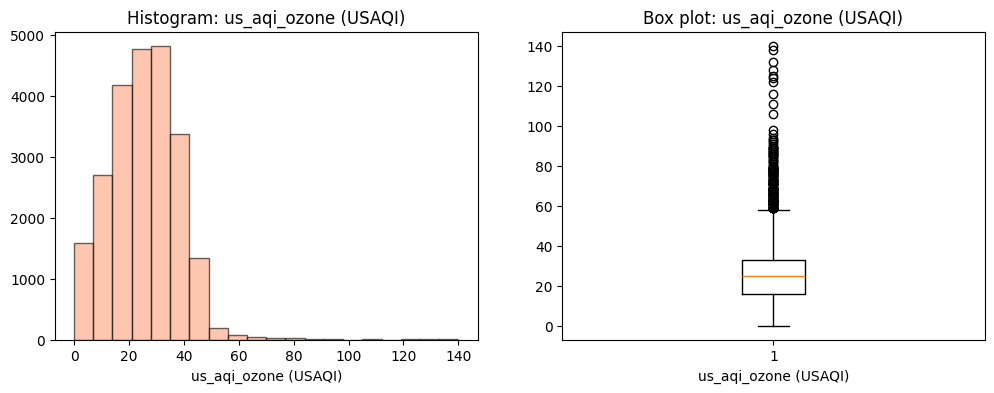

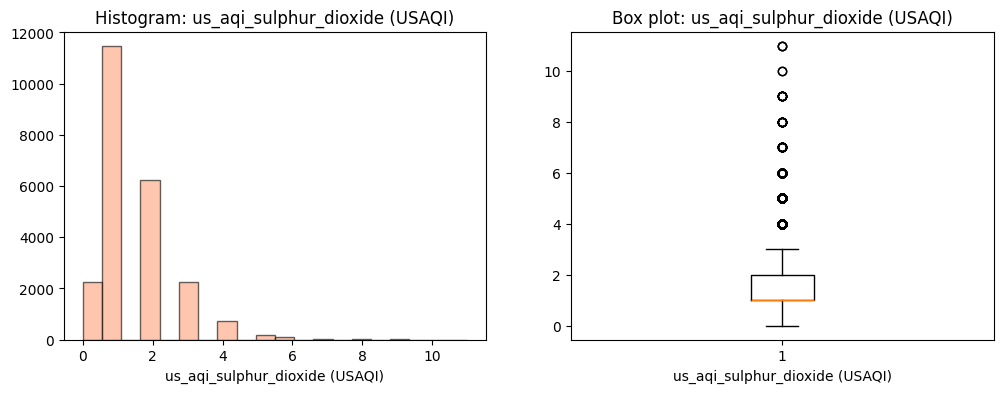

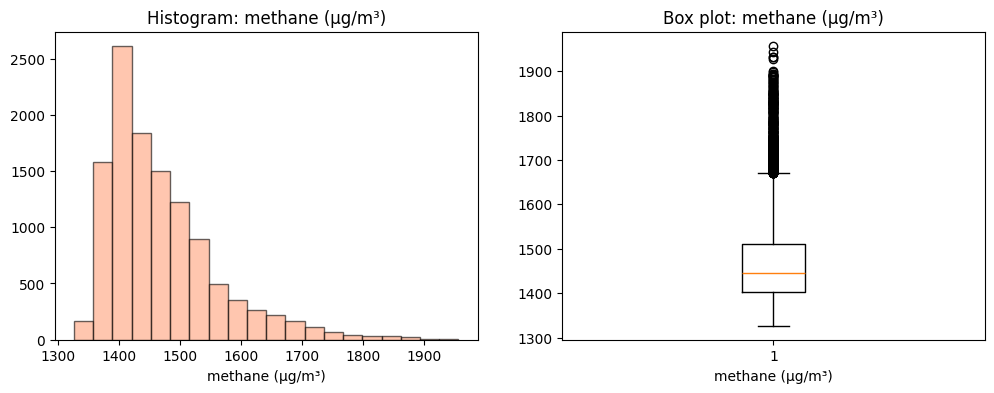

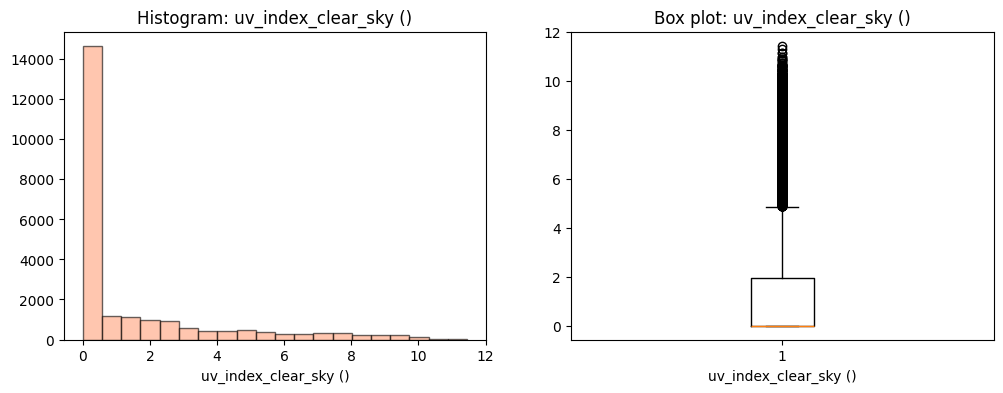

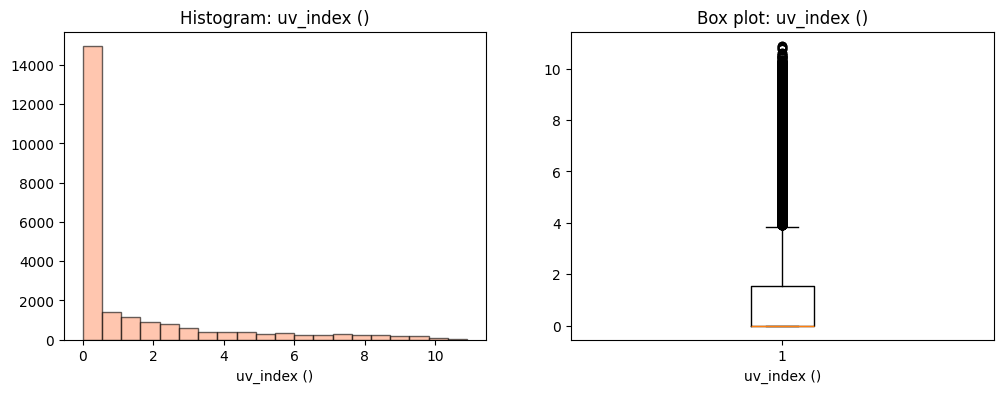

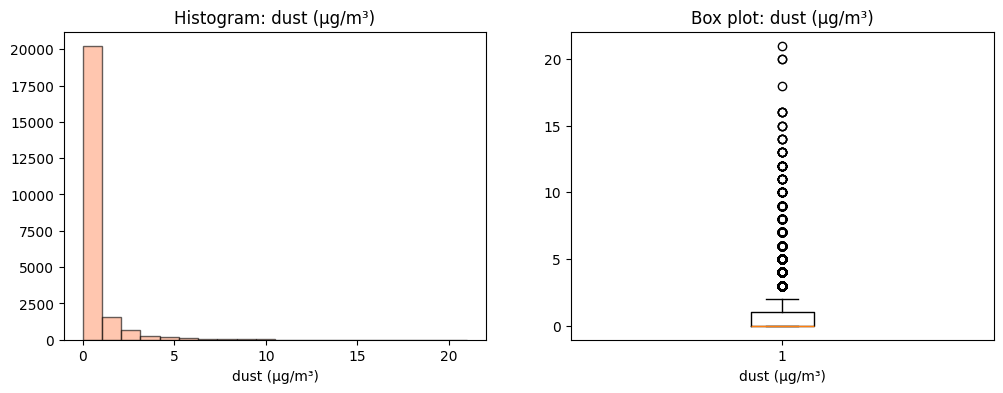

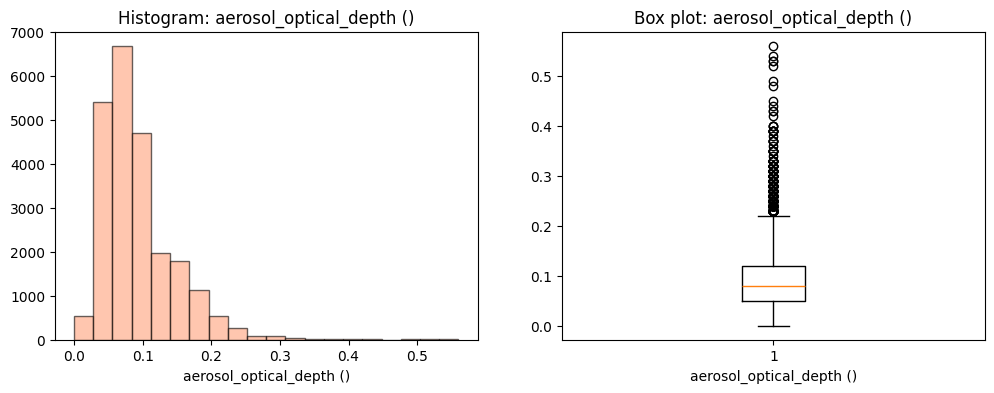

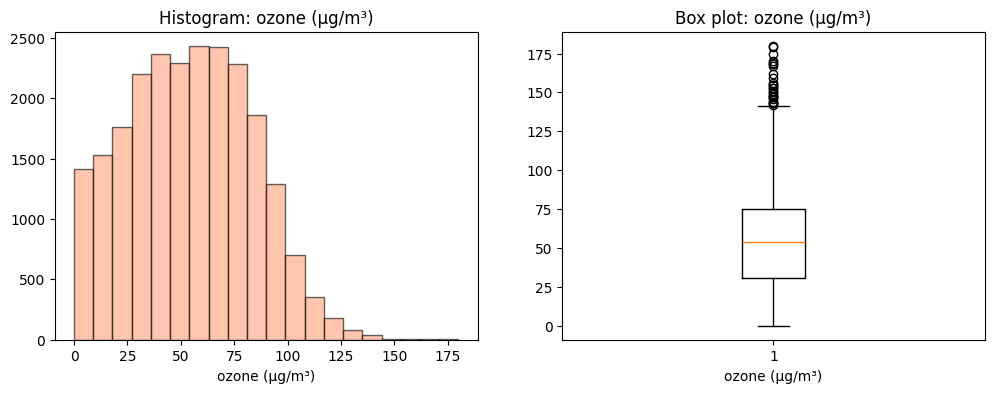

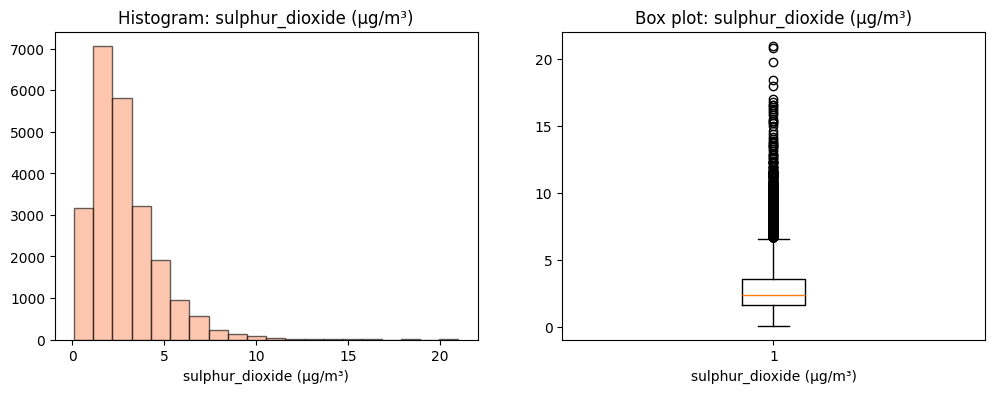

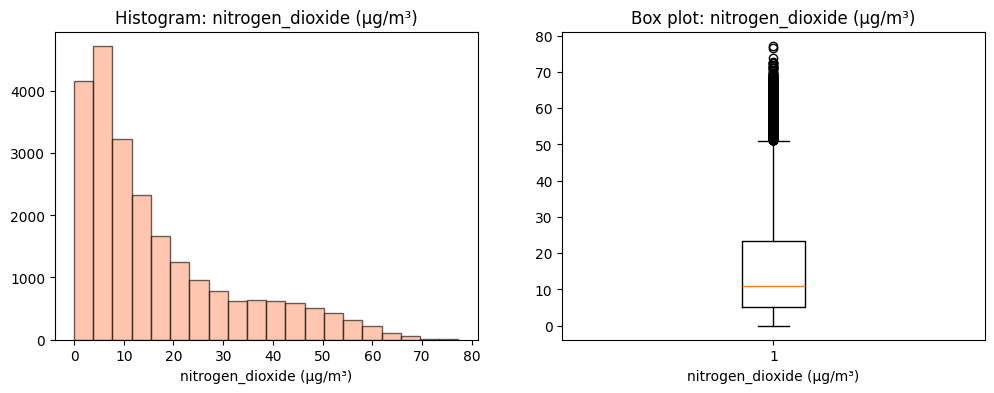

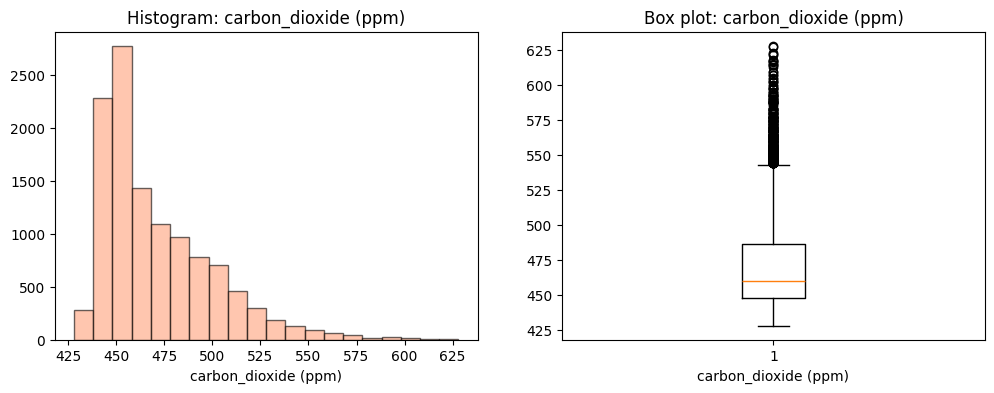

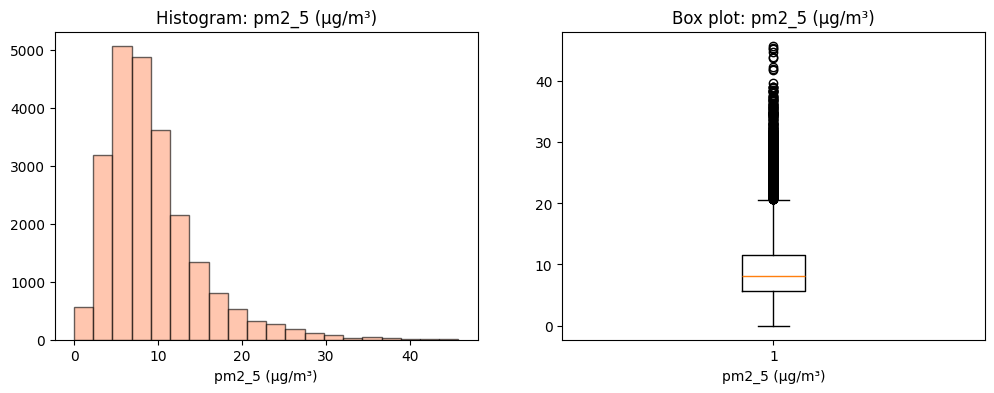

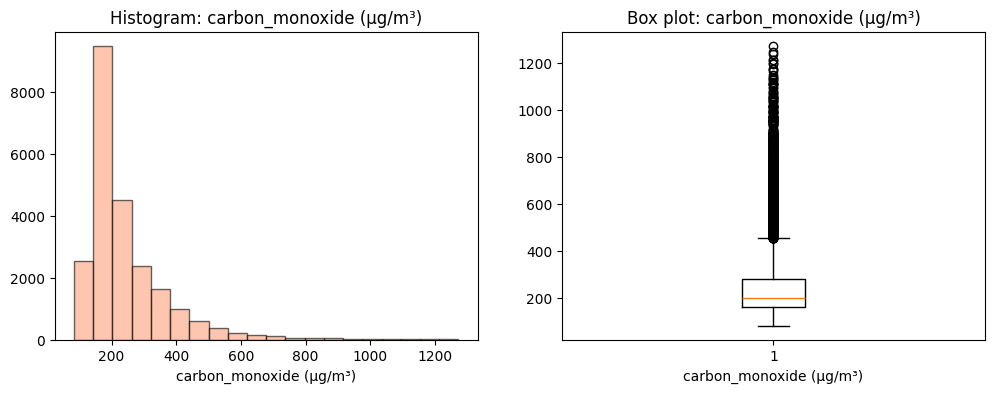

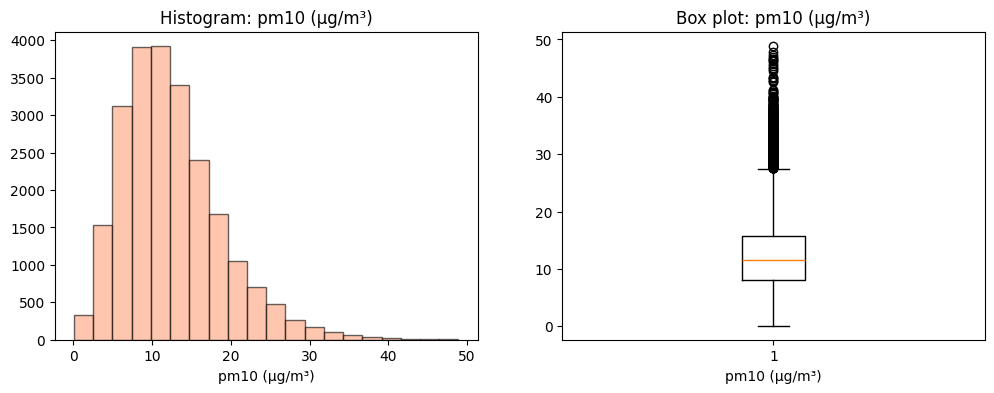

In [88]:
aq_assessment = aq.copy()

# Histogram guide:https://www.stratascratch.com/blog/how-to-create-a-matplotlib-histogram

for key in aq_assessment.columns:
    if not is_numeric_dtype(aq_assessment[key]):
        continue
    v = aq_assessment[key].dropna()
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.title("Histogram: " + key)
    plt.xlabel(key)
    plt.hist(v, alpha = 0.6, bins=20, color='lightsalmon', edgecolor='black')
    
    plt.subplot(1, 2, 2)
    plt.title("Box plot: " + key)
    plt.xlabel(key)
    plt.boxplot(v)
    plt.show()
